In [1]:
from fingerprinter import CNNFingerprinter

In [2]:
import torch
if torch.cuda.is_available():
    torch.cuda.set_per_process_memory_fraction(0.18, device=0)
    print("GPU memorija je uspešno ograničena na 18%.")

GPU memorija je uspešno ograničena na 18%.


In [3]:
spectrogram_path = '/home/jovyan/spectrograms-20260626T174438Z-3-001/spectrograms/936'

In [4]:
import sys
import os

# Putanja do glavnog foldera (prilagodi broj '..' u zavisnosti od toga koliko duboko si u folderima)
project_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))

# Dodajemo ga u Pythonovu listu putanja za pretragu
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(f"Dodata putanja: {project_root}")

Dodata putanja: /home/jovyan/src_zipp


In [5]:
import os
import numpy as np
spectrograms = []
paths = os.listdir(spectrogram_path)
for path in paths:
    spectrograms.append(np.load(os.path.join(spectrogram_path, path)))
spectrograms = np.array(spectrograms)
    

In [6]:
import seaborn as sns

<Axes: >

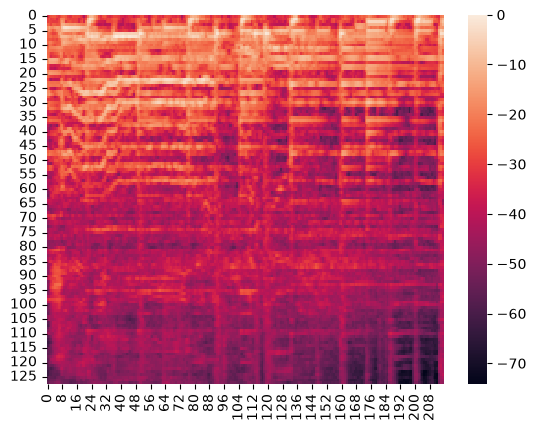

In [7]:
sns.heatmap(spectrograms[0])

In [8]:
# Loads the autoreload extension
%load_ext autoreload

# Tells Jupyter to automatically reload every module every time you execute a cell
%autoreload 2

In [9]:
from src.training.trainer import TrainingPipeline
pipeline = TrainingPipeline()
pipeline.train_cnn(
    train_epochs=2,
    model_num=100
)
print(pipeline.eval_model(model_num = 102))



Ukupno pesama: 448 | Za trening: 359 | Za test: 89
--- Model Architecture Test ---
Input Spectrogram Shape:  torch.Size([64, 1, 128, 216])
Output Embedding Shape:   torch.Size([64, 128])
Test Passed: The model successfully output 128 normalized coordinates per audio clip!

=== EPOCH 1/2 ===


Epoch 1: 100%|██████████| 516/516 [00:40<00:00, 12.68it/s, Loss=1.02, Triplets=177]


Testing on epoch: 1
Baza uspešno izgrađena! Sačuvano 40368 jedinstvenih otisaka.
Baza uspešno izgrađena! Sačuvano 7281 jedinstvenih otisaka.


Mapping labels: 100%|██████████| 7281/7281 [00:09<00:00, 801.63it/s]


Total Queries Evaluated: 7281

--- Performance at K Thresholds ---
Threshold    | Top-K Accuracy  | MRR@K
-------------------------------------------------------
K = 1        | 51.52% (0.515)   | 0.515
K = 2        | 56.48% (0.565)   | 0.540
K = 3        | 59.65% (0.596)   | 0.551
Model uspešno sačuvan na: /home/jovyan/models/audio_resnet_epoch_101.pth

=== EPOCH 2/2 ===


Epoch 2: 100%|██████████| 516/516 [00:43<00:00, 11.88it/s, Loss=1.01, Triplets=165]


Testing on epoch: 2
Baza uspešno izgrađena! Sačuvano 40368 jedinstvenih otisaka.
Baza uspešno izgrađena! Sačuvano 7281 jedinstvenih otisaka.


Mapping labels: 100%|██████████| 7281/7281 [00:17<00:00, 415.15it/s]


Total Queries Evaluated: 7281

--- Performance at K Thresholds ---
Threshold    | Top-K Accuracy  | MRR@K
-------------------------------------------------------
K = 1        | 61.43% (0.614)   | 0.614
K = 2        | 66.72% (0.667)   | 0.641
K = 3        | 69.72% (0.697)   | 0.651
Model uspešno sačuvan na: /home/jovyan/models/audio_resnet_epoch_102.pth


In [10]:
fingerPrinter=CNNFingerprinter(
    run_num = 100
)
embedding = fingerPrinter.fingerprint(spectrograms[0])

Ukupno pesama: 448 | Za trening: 359 | Za test: 89
(128, 216)
torch.Size([1, 1, 128, 216])


In [11]:
print(embedding.shape)

(128,)


In [12]:
# from pipeline.pipeline import RecognitionPipeline